In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [80]:
df= pd.read_csv("2-multiplegradesdataset.csv")

In [81]:
df.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
0,4.7,7.3,82.9,3.3,80.7
1,3.8,6.6,87.9,3.3,76.0
2,5.0,6.3,88.3,2.3,89.1
3,6.3,7.6,86.0,3.2,95.9
4,3.6,8.0,89.2,3.3,70.5


In [82]:
df.describe()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
count,50.00000,50.000000,50.000000,50.00000,50.00000
mean,3.66800,7.022000,89.736000,3.09000,76.07000
std,1.40123,0.874419,4.924813,0.89699,11.70915
min,1.10000,4.400000,80.400000,1.50000,56.90000
25%,2.67500,6.500000,85.625000,2.22500,68.07500
50%,3.60000,7.050000,90.100000,3.20000,73.55000
75%,4.50000,7.575000,92.550000,3.57500,84.17500
max,6.80000,8.600000,100.000000,5.70000,100.00000


In [83]:
df.isnull().sum()

Study Hours           0
Sleep Hours           0
Attendance Rate       0
Social Media Hours    0
Exam Score            0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

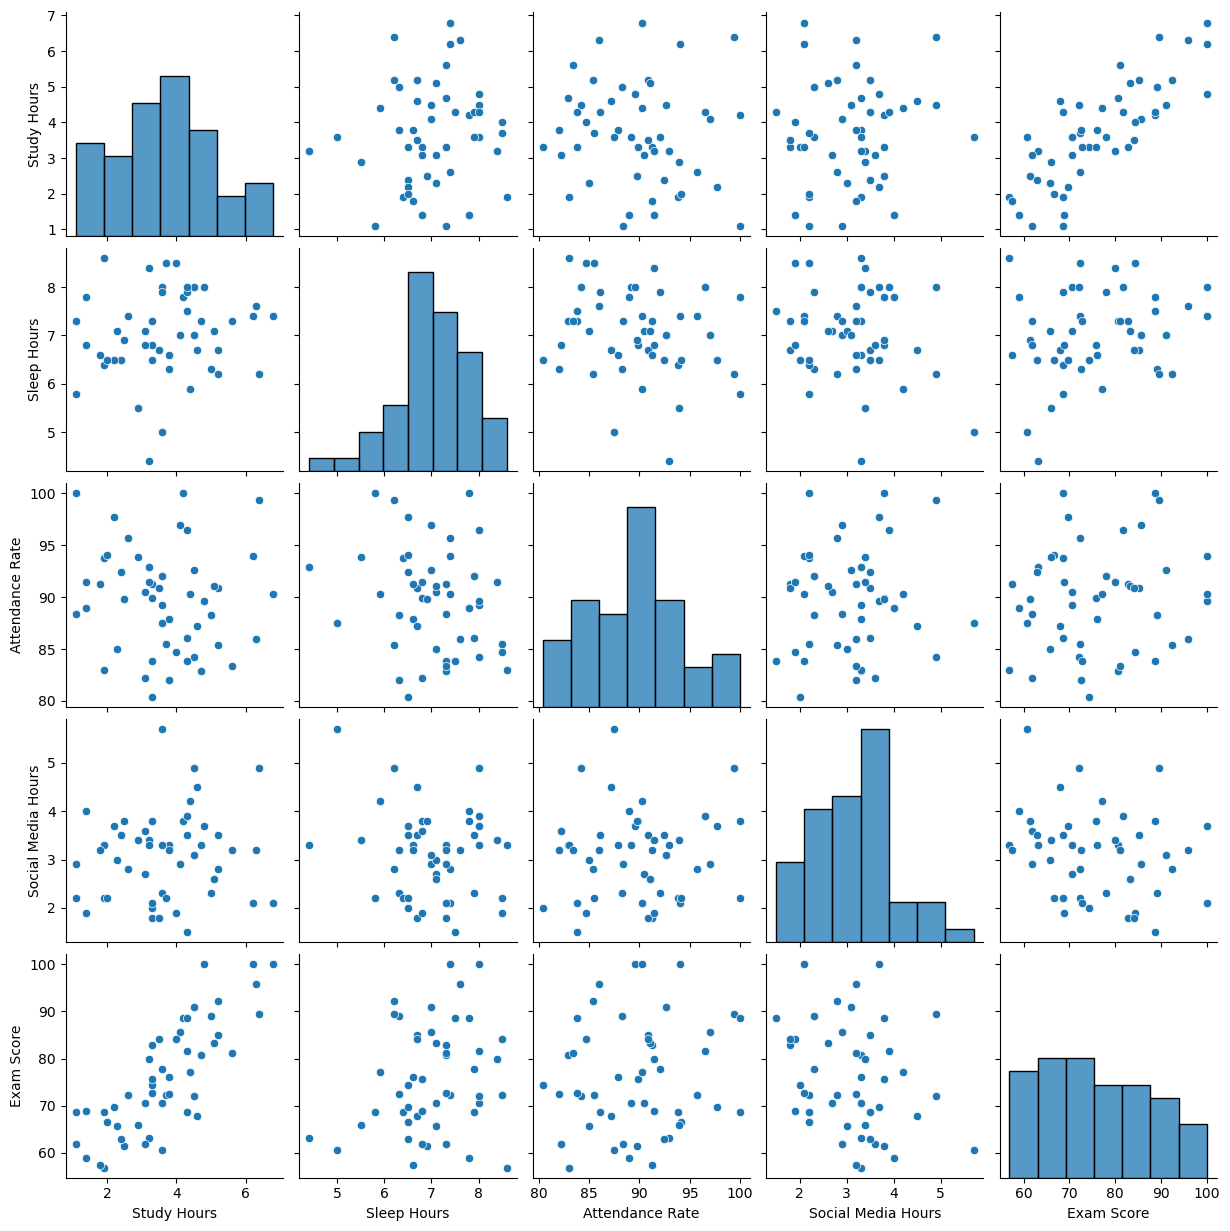

In [84]:
sns.pairplot(df)
plt.show

In [85]:
df.corr()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
Study Hours,1.000000,0.114015,-0.112860,0.115023,0.804266
Sleep Hours,0.114015,1.000000,-0.222024,-0.177166,0.227694
Attendance Rate,-0.112860,-0.222024,1.000000,0.068272,0.123791
Social Media Hours,0.115023,-0.177166,0.068272,1.000000,-0.248743
Exam Score,0.804266,0.227694,0.123791,-0.248743,1.000000


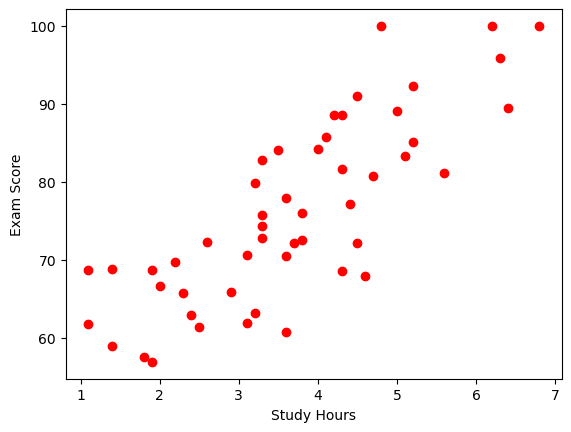

In [86]:
plt.scatter(df['Study Hours'],df['Exam Score'],color ="r")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

In [87]:
# independent and dependent features

In [88]:
X = df[["Study Hours","Sleep Hours","Attendance Rate","Social Media Hours"]]
y= df["Exam Score"]

In [89]:
X.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours
0,4.7,7.3,82.9,3.3
1,3.8,6.6,87.9,3.3
2,5.0,6.3,88.3,2.3
3,6.3,7.6,86.0,3.2
4,3.6,8.0,89.2,3.3


In [90]:
y.head()

0    80.7
1    76.0
2    89.1
3    95.9
4    70.5
Name: Exam Score, dtype: float64

In [91]:
#train - test split

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=15)

In [94]:
from sklearn.preprocessing import StandardScaler

In [95]:
scaler = StandardScaler()

In [96]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [97]:
X_train

array([[-1.78143576e+00,  8.58031639e-01, -1.41558348e-01,
         9.79555204e-01],
       [-9.64092971e-01, -1.13324933e-01,  2.31640933e-02,
         7.66608421e-01],
       [ 1.78515095e+00,  4.26317607e-01,  8.87956911e-01,
        -1.04343924e+00],
       [ 7.44896496e-01,  1.07388866e+00, -1.80165170e-02,
         6.60135029e-01],
       [-1.48422020e+00, -4.37110458e-01,  3.32018671e-01,
         1.27768070e-01],
       [ 1.33932762e+00,  3.18389099e-01, -1.29461544e+00,
         1.27768070e-01],
       [-1.78143576e+00, -2.21253442e-01,  3.73199281e-01,
        -1.25638602e+00],
       [ 2.24769267e-01, -5.39642540e-03,  1.50566607e+00,
        -1.91652105e-01],
       [ 2.99073157e-01,  8.58031639e-01,  2.12337522e+00,
         7.66608421e-01],
       [ 1.85759725e-03, -7.60895982e-01, -1.58287971e+00,
         1.27768070e-01],
       [ 8.93504276e-01, -7.60895982e-01, -2.85690484e-01,
        -8.30492456e-01],
       [-3.69661852e-01,  3.18389099e-01, -1.21225422e+00,
      

In [98]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [99]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [100]:
## prediction
y_pred=regression.predict(X_test)

In [101]:
y_pred

array([67.07303848, 58.17133875, 83.51170406, 63.86802198, 69.67856026,
       80.54614881, 93.47426701, 66.0054829 , 64.7575053 , 78.4249828 ])

In [102]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("mse: ", mse)
print("mae: ", mae)
print("rmse: ", rmse)

mse:  16.903774391462964
mae:  3.4745420268656453
rmse:  4.111419996967345


In [103]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("r2 score: ", score)
#adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

r2 score:  0.8574902951360835
0.7434825312449503


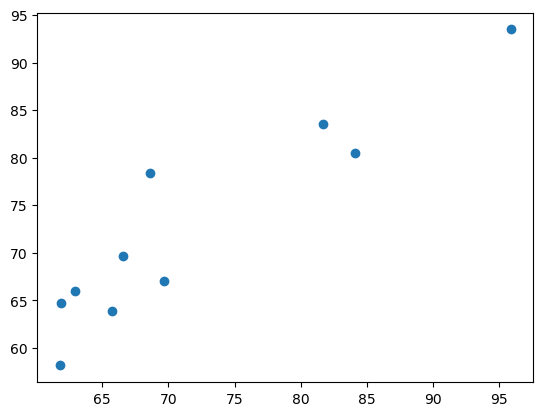

In [104]:

plt.scatter(y_test,y_pred)
plt.show()

In [105]:

residuals=y_test-y_pred
print(residuals)

35    2.626962
37    3.628661
41   -1.811704
26    1.831978
38   -3.078560
43    3.553851
3     2.425733
33   -3.105483
30   -2.857505
36   -9.824983
Name: Exam Score, dtype: float64


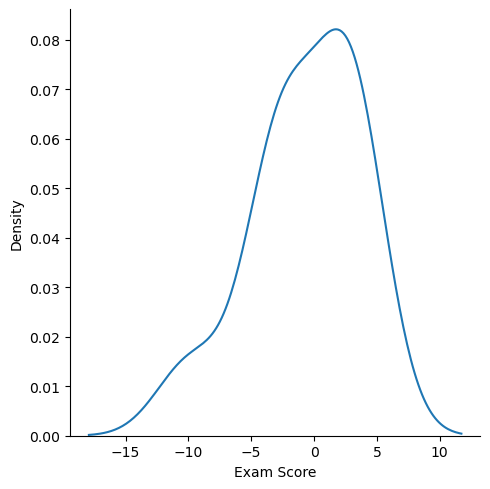

In [106]:
## if residuals are in normal distribution it seems good
sns.displot(residuals,kind='kde')
plt.show()

In [107]:
regression.intercept_

np.float64(77.115)

In [108]:

regression.coef_

array([ 9.70753013,  1.78760804,  3.07311527, -3.96098086])

In [109]:

X.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours
0,4.7,7.3,82.9,3.3
1,3.8,6.6,87.9,3.3
2,5.0,6.3,88.3,2.3
3,6.3,7.6,86.0,3.2
4,3.6,8.0,89.2,3.3


In [110]:
X_test[0]

array([-1.18700464, -0.54503897,  1.6497982 ,  0.66013503])

In [111]:

df.iloc[0]

Study Hours            4.7
Sleep Hours            7.3
Attendance Rate       82.9
Social Media Hours     3.3
Exam Score            80.7
Name: 0, dtype: float64

In [112]:
new_student = [[5, 7, 90, 2]]  # 5 study hours, 7 sleep hours, %90 attendance, 2 social media hours

In [113]:
new_student_scaled = scaler.transform(new_student)

C:\Users\CG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [114]:
predicted_score = regression.predict(new_student_scaled)

In [115]:
predicted_score

array([90.53159361])

In [116]:
students = [
    [6, 8, 95, 5],
    [3, 6, 85, 4],
    [4, 7, 80, 3]
]


In [117]:

predicted_scores = regression.predict(scaler.transform(students))
print(predicted_scores)

[90.18565185 62.5775095  72.7734923 ]


C:\Users\CG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
